## Debug the problem with bispectrum

In [1]:
import os, sys
os.environ["MPICH_GPU_SUPPORT_ENABLED"] = "0"
import numpy as np
from pathlib import Path
from mockfactory import Catalog
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import lsstypes as types
sys.path.append('../../')
from plotting_tools import plot_moll

from cat_tools import get_catalog_fn, get_measurement_fn, read_positions_weights
from fit_tools import read_data_from_fn

%load_ext autoreload
%autoreload 2

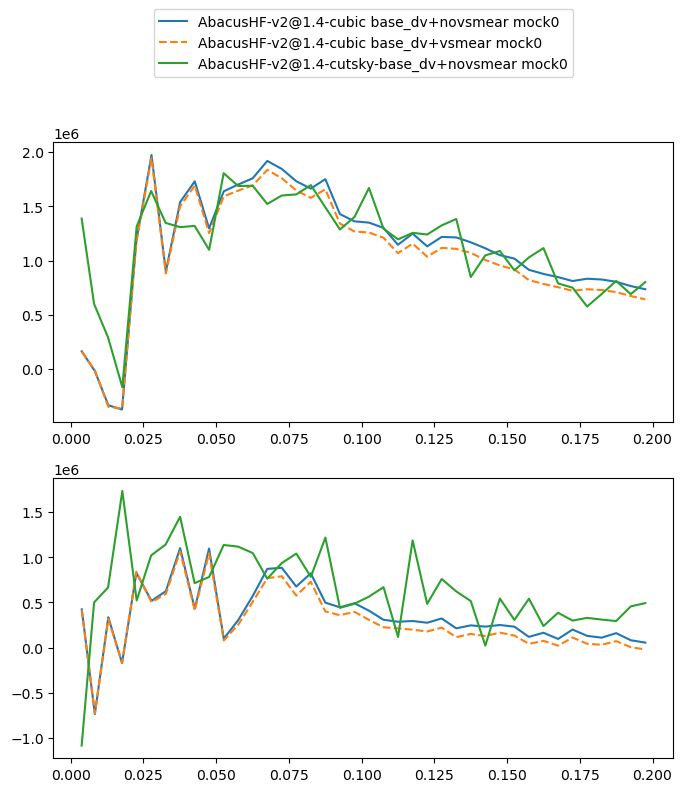

In [6]:
## Bispectrum
from unittest import result

BASE_DIR = '/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base'
MOCK_DIR = '/global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3'

mock_id = 3

fn_hf_cubic_base_dv_vsmear = [f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/mock_challenge/abacushf_MC/v2/QSO/mesh3_spectrum_sugiyama-diagonal_poles_QSO_z1.400_c000_hod-base_dv_los-z_{mock_id}.h5', 'AbacusHF-v2@1.4-cubic base_dv+vsmear mock0']
fn_hf_cubic_base_dv_novsmear = [f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/mock_challenge/abacushf_MC/v2/QSO/mesh3_spectrum_sugiyama-diagonal_poles_QSO_z1.400_c000_hod-base_dv_los-z_novsmear_{mock_id}.h5', 'AbacusHF-v2@1.4-cubic base_dv+novsmear mock0']

fn_hf_cutsky_base_dv_novsmear = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph{mock_id:03}/mpspk/mesh3_spectrum_poles_sugiyama_QSO_z0.8-2.1_hf_v2.0_base_dv.h5', 'AbacusHF-v2@1.4-cutsky-base_dv+novsmear mock0']
# fn_hf_cutsky_base_dv_nonparam = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh3_spectrum_poles_sugiyama_QSO_z0.8-2.1_hf_v2.0_base_dv+dv_verr_nonparam.h5', 'AbacusHF-v2@1.4-cutsky-base_dv+dv_nonparam mock0']

fns = [fn_hf_cubic_base_dv_novsmear, fn_hf_cubic_base_dv_vsmear, fn_hf_cutsky_base_dv_novsmear]

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(2, 1, wspace=0.05)

def read_mean_mesh3(fn_template, mock_ids):
    ks = []
    bks = []
    used = []
    for mock_id in mock_ids:
        fn = fn_template.format(mock_id=mock_id)
        if not os.path.exists(fn):
            # print(f'missing {fn}')
            continue
        (k, pk), _ = read_data_from_fn(fn, 'mesh3_sugiyama')
        ks.append(np.asarray(k))
        bks.append(np.asarray(pk))
        used.append(mock_id)
    if not bks:
        raise FileNotFoundError(f'No mock files found for {fn_template}')
    return ks[0], np.mean(bks, axis=0)

lss = ['-', '--', '-', '--', '-.']
for ill, ell in enumerate([(0,0,0), (2,0,2)]):
    ax = plt.subplot(gs[ill])
    for f, (fn, label) in enumerate(fns):
        mock_ids = np.arange(25)
        if fn.endswith('.h5'):
            (k, bk) = read_mean_mesh3(fn, mock_ids=mock_ids)
        ax.plot(k, k**2*bk[ill], color = f'C{f}', ls =lss[f], label = label)

    # if ill==0:
    #     ax.set_ylabel('$k P_0(k)$', fontsize=12)
    # if ill==1:
    #     ax.set_ylabel('$k P_2(k)$', fontsize=12)
    # if ill==2:
    #     ax.set_ylabel('$k P_4(k)$', fontsize=12)
    #     ax.set_xlabel('$k$ [$h$/Mpc]', fontsize=12)

ax = plt.subplot(gs[0])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2+0.1*len(fns)), fontsize=10)

# Bispectrum cubic vs cutsky validation

This notebook validates the saved QSO Sugiyama-diagonal bispectrum products in `AbacusHF-v2` by comparing the available cubic box files at `z=1.55` to the cutsky files over `0.8 < z < 2.1` for matching phases. Caveat: the current saved cutsky products use `base_dv` naming, while the matching cubic `base_dv` bispectrum files were not found on disk, so this is a saved-product sanity check rather than a perfectly HOD-matched estimator test.

In [3]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lsstypes as types

base = Path('/global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3/AbacusHF-v2')
ells = [(0, 0, 0), (2, 0, 2)]
target_ks = [0.025, 0.05, 0.10, 0.15, 0.20]

def cubic_fn(mock):
    return base / 'boxes/QSO/sn1p550' / f'AbacusSummit_base_c000_ph{mock:03d}' / 'mpspk' / 'mesh3_spectrum_poles_sugiyama_QSO_zp1.550_DR2_v2.0.h5'

def cutsky_fn(mock):
    return base / 'cutsky/QSO' / f'AbacusSummit_base_c000_ph{mock:03d}' / 'mpspk' / 'mesh3_spectrum_poles_sugiyama_QSO_z0.8-2.1_hf_v2.0_base_dv.h5'

pairs = [(i, cubic_fn(i), cutsky_fn(i)) for i in range(25)]
pairs = [(i, c, t) for i, c, t in pairs if c.exists() and t.exists()]
len(pairs), [i for i, _, _ in pairs]

[000004.97]  06-19 00:34  numexpr.utils                INFO     Note: detected 256 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
[000004.97]  06-19 00:34  numexpr.utils                INFO     Note: NumExpr detected 256 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
[000004.97]  06-19 00:34  numexpr.utils                INFO     NumExpr defaulting to 16 threads.


(25,
 [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24])

In [4]:
rows = []
for mock, cfn, tfn in pairs:
    cubic = types.read(str(cfn))
    cutsky = types.read(str(tfn))
    row = {'mock': mock}
    for name, result in [('cubic', cubic), ('cutsky', cutsky)]:
        row[f'{name}_norm'] = float(np.nanmedian(result.get(ells=(0, 0, 0)).values('norm')))
        for ell in ells:
            pole = result.get(ells=ell)
            kval = np.mean(pole.coords('k'), axis=1)
            value = np.asarray(pole.values('value'), dtype='f8')
            for target_k in target_ks:
                idx = int(np.nanargmin(np.abs(kval - target_k)))
                row[f'{name}_{ell}_{target_k:.3f}'] = value[idx]
    rows.append(row)

df = pd.DataFrame(rows)
df.head()

,mock,cubic_norm,"cubic_(0, 0, 0)_0.025","cubic_(0, 0, 0)_0.050","cubic_(0, 0, 0)_0.100","cubic_(0, 0, 0)_0.150","cubic_(0, 0, 0)_0.200","cubic_(2, 0, 2)_0.025","cubic_(2, 0, 2)_0.050","cubic_(2, 0, 2)_0.100",...,"cutsky_(0, 0, 0)_0.025","cutsky_(0, 0, 0)_0.050","cutsky_(0, 0, 0)_0.100","cutsky_(0, 0, 0)_0.150","cutsky_(0, 0, 0)_0.200","cutsky_(2, 0, 2)_0.025","cutsky_(2, 0, 2)_0.050","cutsky_(2, 0, 2)_0.100","cutsky_(2, 0, 2)_0.150","cutsky_(2, 0, 2)_0.200"
0,0,199.514976,2.171740e+09,7.846500e+08,1.353173e+08,4.241283e+07,1.538028e+07,2.294193e+09,2.572978e+08,2.760556e+07,...,1.516007e+08,2.298943e+08,3.524338e+07,1.030175e+07,3.530182e+06,8.128773e+08,1.208037e+08,1.180844e+07,3.298556e+06,3.960570e+06
1,1,198.943027,6.838675e+08,8.223182e+08,1.374304e+08,4.446879e+07,1.632251e+07,1.942820e+08,1.811990e+08,1.752427e+07,...,1.605264e+08,1.520608e+08,4.512630e+07,1.270591e+07,5.320779e+06,2.982532e+08,-3.044472e+07,2.971503e+06,1.839276e+06,5.333996e+05
2,2,198.514146,1.788219e+09,7.836579e+08,1.418664e+08,4.034766e+07,1.527301e+07,1.327944e+09,2.283291e+08,2.162547e+07,...,4.309886e+08,1.919099e+08,4.005921e+07,1.209915e+07,3.766871e+06,1.894274e+08,8.840603e+07,2.061972e+07,5.198824e+06,1.404658e+06
3,3,199.928731,2.523819e+09,5.949825e+08,1.326147e+08,4.161443e+07,1.490818e+07,1.793192e+09,4.146742e+08,2.655431e+07,...,6.266261e+08,1.299042e+08,3.727971e+07,1.303075e+07,5.209155e+06,2.724967e+08,9.627220e+07,1.278923e+07,6.171145e+06,3.371455e+06
4,4,200.147575,1.953360e+09,5.338397e+08,1.379823e+08,3.998246e+07,1.569257e+07,6.194145e+08,2.149270e+08,3.887596e+07,...,5.412948e+08,1.869147e+08,4.262555e+07,1.297962e+07,4.993207e+06,3.417306e+08,4.960986e+07,2.098883e+07,4.899305e+06,-1.159068e+06


In [5]:
summary_rows = []
summary_rows.append({
    'quantity': 'norm',
    'ell': '',
    'k': np.nan,
    'mean_cubic': df['cubic_norm'].mean(),
    'mean_cutsky': df['cutsky_norm'].mean(),
    'signed_ratio_cutsky_over_cubic': df['cutsky_norm'].mean() / df['cubic_norm'].mean(),
    'median_abs_ratio_cutsky_over_cubic': np.median(np.abs(df['cutsky_norm']) / np.abs(df['cubic_norm'])),
})

for ell in ells:
    for target_k in target_ks:
        c = df[f'cubic_{ell}_{target_k:.3f}'].to_numpy()
        t = df[f'cutsky_{ell}_{target_k:.3f}'].to_numpy()
        summary_rows.append({
            'quantity': 'B',
            'ell': str(ell),
            'k': target_k,
            'mean_cubic': np.nanmean(c),
            'mean_cutsky': np.nanmean(t),
            'signed_ratio_cutsky_over_cubic': np.nanmean(t) / np.nanmean(c),
            'median_abs_ratio_cutsky_over_cubic': np.nanmedian(np.abs(t) / (np.abs(c) + 1e-300)),
        })

summary = pd.DataFrame(summary_rows)
summary

,quantity,ell,k,mean_cubic,mean_cutsky,signed_ratio_cutsky_over_cubic,median_abs_ratio_cutsky_over_cubic
0,norm,,NaN,1.994595e+02,1.493027e-02,0.000075,0.000075
1,B,"(0, 0, 0)",0.025,2.393641e+09,4.703720e+08,0.196509,0.205381
2,B,"(0, 0, 0)",0.050,6.818864e+08,1.694862e+08,0.248555,0.254437
3,B,"(0, 0, 0)",0.100,1.385718e+08,3.735912e+07,0.269601,0.276001
4,B,"(0, 0, 0)",0.150,4.146371e+07,1.182092e+07,0.285091,0.285726
5,B,"(0, 0, 0)",0.200,1.527435e+07,4.782416e+06,0.313101,0.318589
6,B,"(2, 0, 2)",0.025,7.935333e+08,2.817463e+08,0.355053,0.222787
7,B,"(2, 0, 2)",0.050,2.062809e+08,6.496578e+07,0.314938,0.270944
8,B,"(2, 0, 2)",0.100,2.335555e+07,1.361446e+07,0.582922,0.514450
9,B,"(2, 0, 2)",0.150,1.971667e+05,3.881196e+06,19.684844,1.864449


Expected validation from the current files: all 25 phases are present. The median normalization ratio is `cutsky/cubic ~ 7.5e-5` (`cubic/cutsky ~ 1.33e4`). For `B000`, the cutsky mean is systematically lower than the cubic mean, about `0.20`, `0.25`, `0.27`, `0.29`, and `0.31` of cubic at `k ~ 0.025`, `0.05`, `0.10`, `0.15`, and `0.20`, respectively. This confirms the reported large cubic/cutsky discrepancy in the saved bispectrum products.

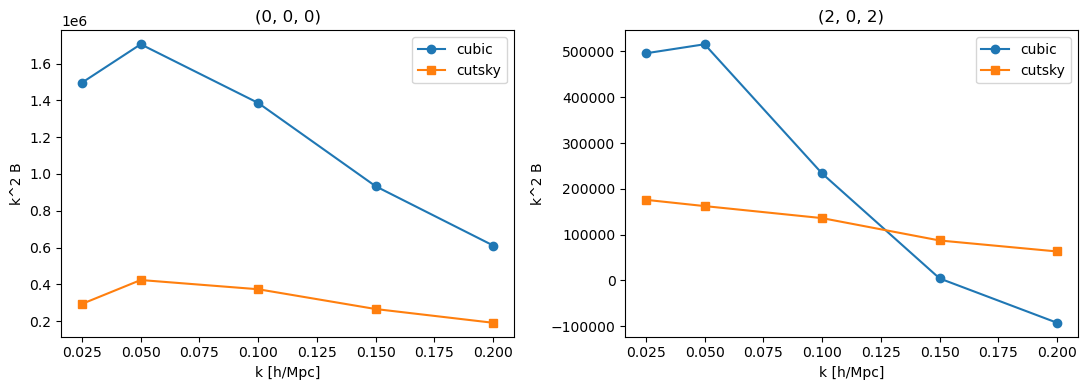

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, ell in zip(axes, ells):
    cmean = []
    tmean = []
    for target_k in target_ks:
        cmean.append(df[f'cubic_{ell}_{target_k:.3f}'].mean())
        tmean.append(df[f'cutsky_{ell}_{target_k:.3f}'].mean())
    ax.plot(target_ks, np.array(cmean) * np.array(target_ks)**2, marker='o', label='cubic')
    ax.plot(target_ks, np.array(tmean) * np.array(target_ks)**2, marker='s', label='cutsky')
    ax.set_title(str(ell))
    ax.set_xlabel('k [h/Mpc]')
    ax.set_ylabel('k^2 B')
    ax.legend()
fig.tight_layout()